In [ ]:
# # Uncomment on Colab

# !pip install exponax optax chaotax trainax pdequinox

In [1]:
import jax
import jax.numpy as jnp
import pdequinox as pdeqx
import equinox as eqx
import trainax as tx
import exponax as ex
import optax
import matplotlib.pyplot as plt
from IPython.display import HTML

/home/koehler/NewRepos/autodiff-jax-workshop-prep/.venv/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [ ]:
DOMAIN_EXTENT = 2 * jnp.pi
DT = 0.1
DIFFUSIVITY = 1e-2

# N_full = 128
N_coarse = 32

# NUM_SAMPLES_TRAIN = 200
# NUM_SAMPLES_TEST = 20

NUM_TIME_STEPS_TRAIN = 100
NUM_TIME_STEPS_TEST = 300

In [ ]:
# # Uncomment on Colab

# !wget https://huggingface.co/datasets/ceyron/jax-ad-workshop/resolve/main/train_trj_set_coarsened.npy

Data was saved in half-precision (float16) to save space, so we have to cast it back to float32

In [3]:
train_trj_set_coarsened = jnp.load("train_trj_set_coarsened.npy").astype(jnp.float32)

Same stepper as before with these differences:

- Coarser spatial resolution
- No substeps
- Default second order integrator instead of fourth order

In [ ]:
stepper_coarse = ex.stepper.KolmogorovFlowVorticity(
    2,
    DOMAIN_EXTENT,
    N_coarse,
    DT,
    diffusivity=DIFFUSIVITY,
)

In [5]:
train_ic_set_coarsened = train_trj_set_coarsened[:, 0]

In [ ]:
train_trj_set_coarse = jax.vmap(
    ex.rollout(stepper_coarse, NUM_TIME_STEPS_TRAIN, include_init=True)
)(train_ic_set_coarsened)

In [7]:
coarse_and_coarsened_together = jnp.concatenate(
    [train_trj_set_coarse[:1], train_trj_set_coarsened[:1]],
    axis=0,
)

In [8]:
ani_coarse_and_coarsened_together = ex.viz.animate_state_2d_facet(
    coarse_and_coarsened_together,
    facet_over_channels=False,
    vlim=(-10, 10),
    grid=(1, 2),
    figsize=(10, 5),
    titles=["Coarse Solver", "Coarsened Fine Solver"],
)

This coarse solver is unstable!

In [ ]:
HTML(ani_coarse_and_coarsened_together.to_jshtml())

~9M parameters, and receptive field of 65 per direction, so it should have global visibility on our domain.

In [10]:
unet_init = pdeqx.arch.ClassicUNet(
    2, 1, 1, hidden_channels=32, num_levels=3, key=jax.random.key(42)
)

pdeqx.count_parameters(unet_init), unet_init.receptive_field

(2336641, ((65.0, 65.0), (65.0, 65.0)))

In [11]:
class HybridSurrogate(eqx.Module):
    corrector: eqx.Module

    def __call__(self, state):
        # A bit dirty: Global closure capture to avoid optimizing the coarse solver
        coarse_next = stepper_coarse(state)
        correction = self.corrector(coarse_next)
        state_next = coarse_next + correction
        return state_next

Check out the docs for details: https://fkoehler.site/trainax/api/trainer/supervised/

Feel free to try and cut the bptt ;)

In [ ]:
one_step_supervised_trainer = tx.trainer.SupervisedTrainer(
    train_trj_set_coarsened,
    optimizer=optax.adam(1e-3),
    num_rollout_steps=1,
    batch_size=16,
    num_training_steps=4_000,
)
three_step_supervised_trainer = tx.trainer.SupervisedTrainer(
    train_trj_set_coarsened,
    optimizer=optax.adam(1e-3),
    num_rollout_steps=3,
    batch_size=16,
    num_training_steps=4_000,
)

In [14]:
hybrid_surrogate_init = HybridSurrogate(unet_init)

In [16]:
hybrid_surrogate_trained, hybrid_loss_history = one_step_supervised_trainer(
    hybrid_surrogate_init,
    key=jax.random.key(100),
)

E: 00003, B: 00249: 100%|██████████| 4000/4000 [00:43<00:00, 92.48it/s] 


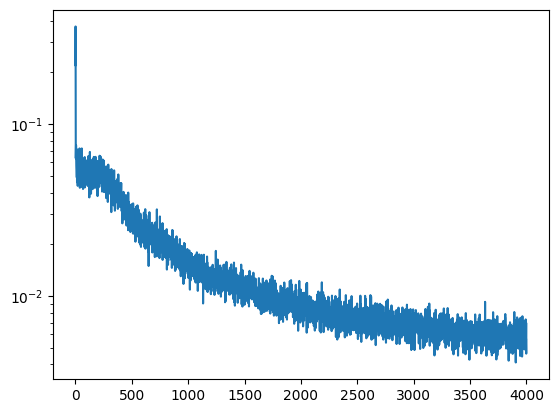

In [17]:
plt.semilogy(hybrid_loss_history)

In [20]:
predictor_surrogate_trained, predictor_surrogate_loss_history = (
    one_step_supervised_trainer(
        unet_init,
        key=jax.random.key(100),
    )
)

E: 00003, B: 00249: 100%|██████████| 4000/4000 [00:40<00:00, 98.39it/s] 


Notice that the training takes ~3 times as long

In [21]:
three_step_hybrid_surrogate_trained, three_step_hybrid_loss_history = (
    three_step_supervised_trainer(
        hybrid_surrogate_init,
        key=jax.random.key(100),
    )
)

E: 00003, B: 00324: 100%|██████████| 4000/4000 [01:50<00:00, 36.29it/s]


In [22]:
three_step_predictor_surrogate_trained, three_step_predictor_surrogate_loss_history = (
    three_step_supervised_trainer(
        unet_init,
        key=jax.random.key(100),
    )
)

E: 00003, B: 00324: 100%|██████████| 4000/4000 [01:43<00:00, 38.52it/s]


The three-step losses are also about ~3 times higher because internally `Trainax` does not use a mean but a sum reduction over the temporal loss components.

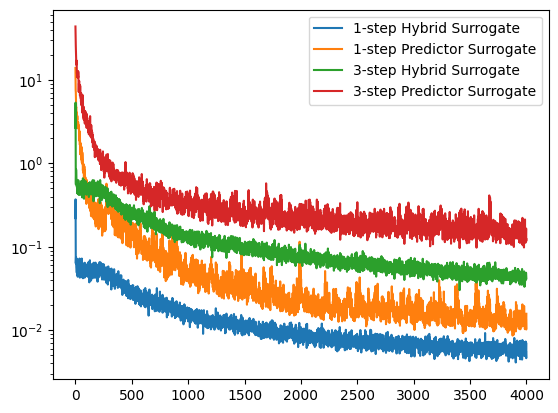

In [23]:
plt.semilogy(hybrid_loss_history, label="1-step Hybrid Surrogate")
plt.semilogy(predictor_surrogate_loss_history, label="1-step Predictor Surrogate")
plt.semilogy(three_step_hybrid_loss_history, label="3-step Hybrid Surrogate")
plt.semilogy(
    three_step_predictor_surrogate_loss_history, label="3-step Predictor Surrogate"
)
plt.legend()

In [ ]:
# # Uncomment on Colab

# !wget https://huggingface.co/datasets/ceyron/jax-ad-workshop/resolve/main/test_trj_set_coarsened.npy

In [24]:
test_trj_set_coarsened = jnp.load("test_trj_set_coarsened.npy").astype(jnp.float32)

In [25]:
test_ic_set_coarsened = test_trj_set_coarsened[:, 0]

In [26]:
test_trj_set_coarse = jax.vmap(
    ex.rollout(stepper_coarse, NUM_TIME_STEPS_TEST, include_init=True)
)(test_ic_set_coarsened)

In [27]:
hybrid_rollout_test = jax.vmap(
    ex.rollout(
        hybrid_surrogate_trained,
        NUM_TIME_STEPS_TEST,
        include_init=True,
    )
)(test_ic_set_coarsened)

In [28]:
predictor_surrogate_rollout_test = jax.vmap(
    ex.rollout(
        predictor_surrogate_trained,
        NUM_TIME_STEPS_TEST,
        include_init=True,
    )
)(test_ic_set_coarsened)

In [29]:
three_step_hybrid_rollout_test = jax.vmap(
    ex.rollout(
        three_step_hybrid_surrogate_trained,
        NUM_TIME_STEPS_TEST,
        include_init=True,
    )
)(test_ic_set_coarsened)

In [30]:
three_step_predictor_surrogate_rollout_test = jax.vmap(
    ex.rollout(
        three_step_predictor_surrogate_trained,
        NUM_TIME_STEPS_TEST,
        include_init=True,
    )
)(test_ic_set_coarsened)

In [31]:
neural_and_test_stacked = jnp.concatenate(
    [
        hybrid_rollout_test[:1],
        three_step_hybrid_rollout_test[:1],
        test_trj_set_coarse[:1],
        predictor_surrogate_rollout_test[:1],
        three_step_predictor_surrogate_rollout_test[:1],
        test_trj_set_coarsened[:1],
    ],
    axis=0,
)

In [32]:
ani_together = ex.viz.animate_state_2d_facet(
    neural_and_test_stacked,
    facet_over_channels=False,
    vlim=(-10, 10),
    grid=(2, 3),
    figsize=(15, 10),
    titles=[
        "Hybrid Surrogate",
        "3-Step Hybrid Surrogate",
        "Coarse Solver",
        "Predictor Surrogate",
        "3-Step Predictor Surrogate",
        "True Dynamics",
    ],
)

Keep in mind that the Lyapunov time is approx. 27 time steps (2.7 time units)

In [ ]:
HTML(ani_together.to_jshtml())

In [34]:
neural_and_test_stacked.shape

(6, 301, 1, 32, 32)

In [40]:
spectra = jax.vmap(ex.get_spectrum)(neural_and_test_stacked[:, :, 0]).mean(1)

(0.001, 10.0)

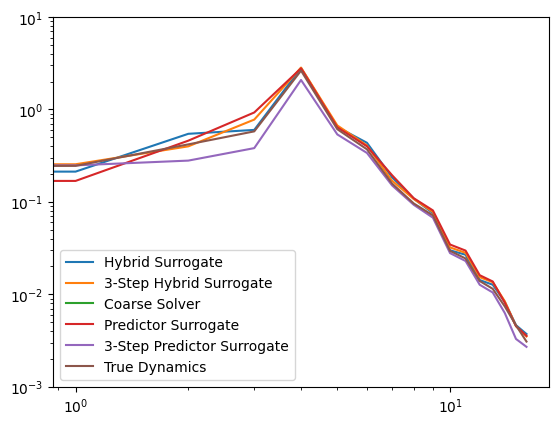

In [41]:
plt.loglog(
    spectra.T,
    label=[
        "Hybrid Surrogate",
        "3-Step Hybrid Surrogate",
        "Coarse Solver",
        "Predictor Surrogate",
        "3-Step Predictor Surrogate",
        "True Dynamics",
    ],
)
plt.legend()
plt.ylim(1e-3, 1e1)

In [42]:
spectra.shape

(6, 17)

In [44]:
spectra_distance = jnp.abs(spectra[:5] - spectra[5:]) / jnp.abs(spectra[5:])

(0.001, 1.0)

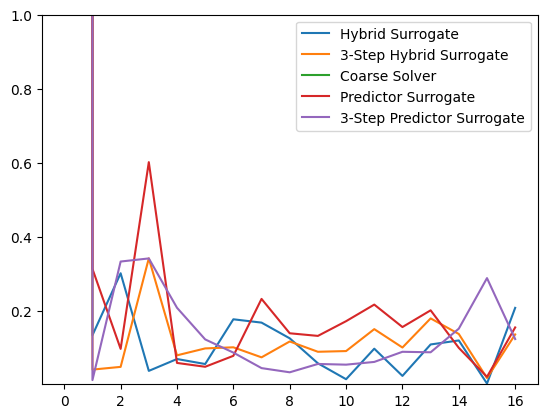

In [50]:
plt.plot(
    spectra_distance.T,
    label=[
        "Hybrid Surrogate",
        "3-Step Hybrid Surrogate",
        "Coarse Solver",
        "Predictor Surrogate",
        "3-Step Predictor Surrogate",
    ],
)
plt.legend()
plt.ylim(1e-3, 1e0)

In [51]:
error_rollout_coarse = jax.vmap(jax.vmap(ex.metrics.nRMSE))(
    test_trj_set_coarse,
    test_trj_set_coarsened,
)

In [52]:
error_rollout_hybrid = jax.vmap(jax.vmap(ex.metrics.nRMSE))(
    hybrid_rollout_test,
    test_trj_set_coarsened,
)

In [53]:
error_rollout_predictor = jax.vmap(jax.vmap(ex.metrics.nRMSE))(
    predictor_surrogate_rollout_test,
    test_trj_set_coarsened,
)

In [54]:
error_rollout_three_step_hybrid = jax.vmap(jax.vmap(ex.metrics.nRMSE))(
    three_step_hybrid_rollout_test,
    test_trj_set_coarsened,
)

In [55]:
error_rollout_three_step_predictor = jax.vmap(jax.vmap(ex.metrics.nRMSE))(
    three_step_predictor_surrogate_rollout_test,
    test_trj_set_coarsened,
)

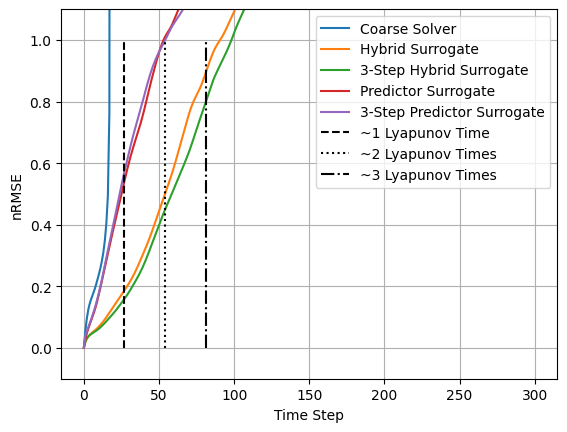

In [61]:
plt.plot(
    jnp.mean(error_rollout_coarse, axis=0),
    label="Coarse Solver",
)
plt.plot(
    jnp.mean(error_rollout_hybrid, axis=0),
    label="Hybrid Surrogate",
)
plt.plot(
    jnp.mean(error_rollout_three_step_hybrid, axis=0),
    label="3-Step Hybrid Surrogate",
)
plt.plot(
    jnp.mean(error_rollout_predictor, axis=0),
    label="Predictor Surrogate",
)
plt.plot(
    jnp.mean(error_rollout_three_step_predictor, axis=0),
    label="3-Step Predictor Surrogate",
)
plt.xlabel("Time Step")
plt.ylabel("nRMSE")
plt.ylim(-0.1, 1.1)
plt.grid()
plt.vlines(27, ymin=0, ymax=1, color="k", linestyle="--", label="~1 Lyapunov Time")
plt.vlines(54, ymin=0, ymax=1, color="k", linestyle=":", label="~2 Lyapunov Times")
plt.vlines(81, ymin=0, ymax=1, color="k", linestyle="-.", label="~3 Lyapunov Times")
plt.legend()

Feel free to play around:

- Change optimizer settings
- Change number of unrolled settings
- Cut the bptt
- Introduce time-level weights
- Try a bigger network

(And if you are interested as a homework: try a larger dataset)

Can you get a better rollout?